# Forecast Accuracy — Rolling-Origin Backtesting

"How accurate were the model's forecasts on data it had not seen?" is the
first question a client asks and the one most MMM write-ups quietly skip —
including, until this notebook, ours. In-sample fit answers a different
question (the posterior can trace the training KPI beautifully and still
forecast poorly), so this notebook grades **genuine out-of-time forecasts**:

1. **The protocol** — rolling-origin backtesting: refit on an expanding
   training window, forecast a fixed horizon past each cutoff, grade against
   held-out actuals. No information from the forecast window reaches the fit.
2. **Headline accuracy** — MAPE / sMAPE / RMSE / MASE vs two honest baselines
   (last-value naive and seasonal-naive). A model that can't beat
   "copy last year" has no business forecasting.
3. **Accuracy by horizon** — how error grows with lead time.
4. **Interval calibration** — does the 80% interval cover ~80% of held-out
   actuals? Tight-but-wrong intervals are the failure mode this catches.
5. **A negative control** — the same harness on the trend-break world, where
   a linear-trend model *should* (and does) forecast worse: the harness
   detects forecastability failures, not just successes.

**Doctrine, stated up front:** forecast accuracy validates the *predictive*
model, not the causal one. A model can forecast well while attributing
wrongly (the confounded worlds in the stress series forecast fine), and a
well-calibrated causal model can forecast poorly in a regime shift. Backtests
belong *alongside* the pressure-testing and experiment-calibration machinery,
never instead of it.

> Library: `mmm_framework.validation.backtest` (`BacktestConfig`,
> `run_backtest`, `PosteriorForecaster`). Companions:
> `nbs/mmm_walkthrough.ipynb` (the modeling workflow on this same world),
> `nbs/stress_00_the_rosy_picture.ipynb` (why green diagnostics ≠ correct
> attribution — the mirror image of this notebook's doctrine).

In [1]:
import sys, pathlib, json, time, warnings, logging
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
# pymc emits sampler warnings at ERROR level -> CRITICAL to keep outputs clean
for _n in ("pymc", "numpyro", "jax", "arviz", "pytensor"):
    logging.getLogger(_n).setLevel(logging.CRITICAL)
try:  # the validation suite logs via loguru, which bypasses stdlib logging
    from loguru import logger as _loguru
    _loguru.disable("mmm_framework")
except ImportError:
    pass
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from mmm_framework.synth import dgp

ARTIFACTS = pathlib.Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
C_ACTUAL, C_PRED, C_BAND, C_NAIVE = "#1a1a2e", "#c0392b", "#c0392b", "#7f8c8d"
print("synthetic worlds available:", len(dgp.SCENARIOS))

synthetic worlds available: 22


## 1 — The world and the protocol

We backtest on the **realistic** world from the stress harness: 156 weeks,
7 channels (TV through Print), 13 candidate controls, confounded spend,
seasonality, trend, and low per-channel signal-to-noise — the same world the
modeling walkthrough fights through. Because the series is synthetic the
*attribution* truth is known, but this notebook never uses it: forecasts are
graded purely against held-out observations, exactly as they would be on
client data. **This protocol requires no ground truth — it runs on any
engagement.**

**Rolling-origin protocol.** First training window = 104 weeks (two seasonal
cycles). At each cutoff T ∈ {104, 117, 130, 143} we refit the full model on
weeks [0, T) and forecast weeks [T, T+13) — a quarter ahead. That yields
4 refits and 52 graded weekly forecasts, every one out-of-time.

Two details that make this honest where shortcuts wouldn't be:

- **Carryover crosses the cutoff correctly.** Adstock at forecast week T+h
  depends on spend back through the training window; the forecaster convolves
  the full spend history with each posterior draw's kernel rather than
  restarting at zero.
- **The forecast window's spend is the *planned* spend.** Media and controls
  in the forecast window are inputs (known plans), the KPI is not — the
  standard conditional-forecast setting for budget planning.

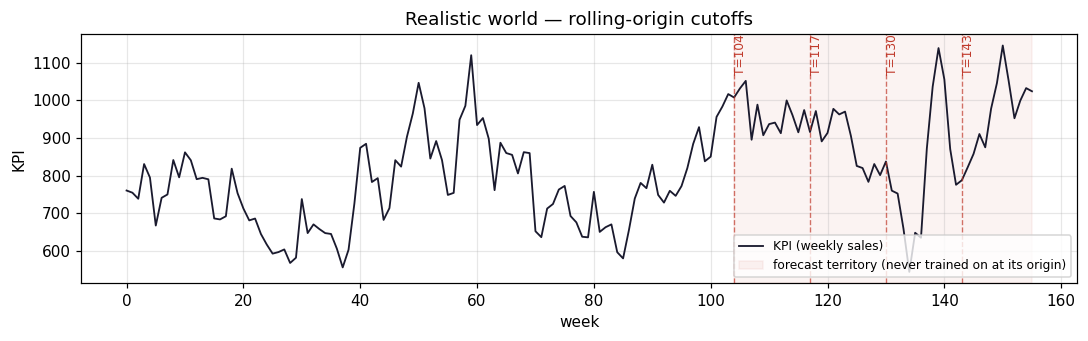

✓ world loaded: 156 weeks x 7 channels, 4 origins x 13-week horizon = 52 graded forecasts


In [2]:
sc = dgp.build("realistic")
panel = sc.panel()
y = sc.y.to_numpy(float)
n_weeks, n_channels = len(sc.weeks), len(sc.channels)

ORIGINS = [104, 117, 130, 143]
HORIZON = 13

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(np.arange(n_weeks), y, color=C_ACTUAL, lw=1.2, label="KPI (weekly sales)")
for i, o in enumerate(ORIGINS):
    ax.axvline(o, color=C_PRED, ls="--", lw=0.9, alpha=0.7)
    ax.annotate(f"T={o}", (o, ax.get_ylim()[1]), fontsize=8, color=C_PRED,
                ha="left", va="top", rotation=90)
ax.axvspan(ORIGINS[0], n_weeks - 1, color=C_BAND, alpha=0.06,
           label="forecast territory (never trained on at its origin)")
ax.set(xlabel="week", ylabel="KPI", title="Realistic world — rolling-origin cutoffs")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

assert (n_weeks, n_channels) == (156, 7)
assert ORIGINS == [104, 117, 130, 143]
print(f"✓ world loaded: {n_weeks} weeks x {n_channels} channels, "
      f"{len(ORIGINS)} origins x {HORIZON}-week horizon = "
      f"{len(ORIGINS) * HORIZON} graded forecasts")

## 2 — Run the backtest

The model is the walkthrough's production configuration: parametric
(in-graph) adstock, logistic saturation, linear trend, yearly seasonality,
NumPyro NUTS. `run_backtest` refits this exact specification at each cutoff —
same priors, same structure, no per-origin tuning (that would be the
specification-shopping this site exists to prevent).

The `fits` table is the first thing to read: a backtest is only as good as
its refits, so R-hat and divergences are recorded per origin. A non-converged
refit would disqualify that origin's row, not get silently averaged in.

In [3]:
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType
from mmm_framework.validation import BacktestConfig, run_backtest

def build_model(panel, seed=11):
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_chains=4, n_draws=500, n_tune=500,
        use_parametric_adstock=True,
        optim_seed=seed,
    )
    return BayesianMMM(panel, cfg, TrendConfig(type=TrendType.LINEAR))

bt_config = BacktestConfig(
    min_train_size=104, horizon=13, step=13,
    draws=500, tune=500, chains=4,
    coverage_levels=(0.5, 0.8, 0.95),
    random_seed=11,
)

t0 = time.time()
with quiet():
    bt = run_backtest(build_model(panel), bt_config, progressbar=False)
bt_elapsed = time.time() - t0

fits = bt.fits.round({"fit_seconds": 1, "rhat_max": 3})
print(fits.to_string())
print(f"\ntotal wall-clock: {bt_elapsed:.0f}s "
      f"({bt.fits['fit_seconds'].sum():.0f}s in {len(bt.fits)} refits)")

# CLAIM: every refit converged -- the accuracy numbers below are admissible.
assert bt.n_origins == 4 and len(bt.records) == 52
assert (bt.fits["rhat_max"] < 1.05).all(), "a backtest refit failed to converge"
print("✓ 4 refits, all converged: the backtest grades a healthy sampler")

Sampling: [adstock_alpha_Display, adstock_alpha_Print, adstock_alpha_Radio, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, adstock_alpha_Video, beta_Display, beta_Print, beta_Radio, beta_Search, beta_Social, beta_TV, beta_Video, beta_controls, intercept, sat_lam_Display, sat_lam_Print, sat_lam_Radio, sat_lam_Search, sat_lam_Social, sat_lam_TV, sat_lam_Video, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, adstock_alpha_Video, sat_lam_Video, beta_Video, adstock_alpha_Radio, sat_lam_Radio, beta_Radio, adstock_alpha_Print, sat_lam_Print, beta_Print, beta_controls, sigma]


Sampling: [adstock_alpha_Display, adstock_alpha_Print, adstock_alpha_Radio, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, adstock_alpha_Video, beta_Display, beta_Print, beta_Radio, beta_Search, beta_Social, beta_TV, beta_Video, beta_controls, intercept, sat_lam_Display, sat_lam_Print, sat_lam_Radio, sat_lam_Search, sat_lam_Social, sat_lam_TV, sat_lam_Video, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, adstock_alpha_Video, sat_lam_Video, beta_Video, adstock_alpha_Radio, sat_lam_Radio, beta_Radio, adstock_alpha_Print, sat_lam_Print, beta_Print, beta_controls, sigma]


Sampling: [adstock_alpha_Display, adstock_alpha_Print, adstock_alpha_Radio, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, adstock_alpha_Video, beta_Display, beta_Print, beta_Radio, beta_Search, beta_Social, beta_TV, beta_Video, beta_controls, intercept, sat_lam_Display, sat_lam_Print, sat_lam_Radio, sat_lam_Search, sat_lam_Social, sat_lam_TV, sat_lam_Video, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, adstock_alpha_Video, sat_lam_Video, beta_Video, adstock_alpha_Radio, sat_lam_Radio, beta_Radio, adstock_alpha_Print, sat_lam_Print, beta_Print, beta_controls, sigma]


Sampling: [adstock_alpha_Display, adstock_alpha_Print, adstock_alpha_Radio, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, adstock_alpha_Video, beta_Display, beta_Print, beta_Radio, beta_Search, beta_Social, beta_TV, beta_Video, beta_controls, intercept, sat_lam_Display, sat_lam_Print, sat_lam_Radio, sat_lam_Search, sat_lam_Social, sat_lam_TV, sat_lam_Video, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, adstock_alpha_Video, sat_lam_Video, beta_Video, adstock_alpha_Radio, sat_lam_Radio, beta_Radio, adstock_alpha_Print, sat_lam_Print, beta_Print, beta_controls, sigma]


        train_size  fit_seconds  rhat_max  divergences
origin                                                
104            104         17.1     1.006            0
117            117         17.4     1.008            0
130            130         17.2     1.009            0
143            143         18.8     1.007            0

total wall-clock: 71s (71s in 4 refits)
✓ 4 refits, all converged: the backtest grades a healthy sampler


## 3 — Headline accuracy: the model vs honest baselines

MAPE alone flatters any model on a seasonal series, so the table includes the
two baselines every forecasting reviewer asks for:

- **naive (last value)** — carry the cutoff week's KPI forward 13 weeks;
- **seasonal-naive** — copy the same week last year (the serious baseline on
  seasonal retail-like data);
- **MASE** — mean absolute error scaled by the in-sample seasonal-naive
  error: **< 1 means the model beats "copy last year"** where the baseline is
  computable, with scale-free aggregation across origins.

In [4]:
summary = bt.summary()
disp = summary.copy()
for c in ("mape", "smape"):
    disp[c] = (disp[c] * 100).round(1)
for c in ("rmse", "mae", "bias"):
    disp[c] = disp[c].round(1)
disp["mase"] = disp["mase"].round(2)
for c in [c for c in disp.columns if c.startswith("coverage")]:
    disp[c] = (disp[c] * 100).round(1)
print(disp.to_string())

mmm_mape = float(summary.loc["mmm", "mape"])
snaive_mape = float(summary.loc["seasonal_naive", "mape"])
naive_mape = float(summary.loc["naive_last_value", "mape"])
mmm_mase = float(summary.loc["mmm", "mase"])

# CLAIM: the MMM's out-of-time forecasts beat both naive baselines on this
# world, and beat copy-last-year on the scale-free MASE.
assert mmm_mape < snaive_mape, "MMM lost to the seasonal-naive baseline"
assert mmm_mape < naive_mape, "MMM lost to the last-value baseline"
assert mmm_mase < 1.0, f"MASE {mmm_mase:.2f} >= 1: no skill over seasonal naive"
print(f"✓ skill confirmed: MMM MAPE {mmm_mape:.1%} vs seasonal-naive "
      f"{snaive_mape:.1%} and naive {naive_mape:.1%}; MASE {mmm_mase:.2f} < 1")

                  mape  smape   rmse    mae   bias  mase  coverage_50  coverage_80  coverage_95
model                                                                                          
mmm                3.0    2.9   34.3   25.8   -5.6  0.24         59.6         88.5         94.2
seasonal_naive    13.8   15.2  160.6  128.8 -110.0  1.19          NaN          NaN          NaN
naive_last_value  13.2   13.4  150.6  117.9  -15.0  1.07          NaN          NaN          NaN
✓ skill confirmed: MMM MAPE 3.0% vs seasonal-naive 13.8% and naive 13.2%; MASE 0.24 < 1


## 4 — Accuracy by horizon

Classical forecasters expect error to grow with lead time. Here it barely
does, and the reason is structural, not lucky: **this model has no
autoregressive term.** Week T+1 gets no special advantage from knowing week
T's KPI — every horizon is predicted from the same ingredients (planned
media through the adstock kernel, controls, periodic seasonality, and a
trend line), and only the trend extrapolation degrades with distance, slowly
over a single quarter. So the per-horizon error profile should be roughly
flat across 13 weeks, and materially below the seasonal-naive baseline at
every lead time. That flatness is a *feature* for budget planning (a
quarter-out forecast is nearly as good as a week-out one) and a *warning*
for anyone wanting short-range operational forecasts, where AR-style models
have an advantage this one deliberately forgoes.

Caveat on granularity: with 4 origins, each horizon's MAPE averages only 4
observations — read the level and the band, not wiggle-by-wiggle.

         mape  snaive_mape  rmse  coverage_80  coverage_95
horizon                                                   
1         3.1         12.8  35.6         75.0        100.0
2         3.7         13.3  34.5        100.0        100.0
3         3.2         10.4  47.3         75.0         75.0
4         3.2         10.3  31.2         75.0        100.0
5         4.7         17.3  43.1         75.0         75.0
6         2.1         14.1  22.0        100.0        100.0
7         5.1         15.3  53.7         75.0         75.0
8         2.0         23.2  24.6        100.0        100.0
9         2.2         17.9  27.4        100.0        100.0
10        2.9         14.4  37.2         75.0        100.0
11        1.4          9.6  13.6        100.0        100.0
12        2.0         12.5  20.1        100.0        100.0
13        2.9          8.0  32.8        100.0        100.0


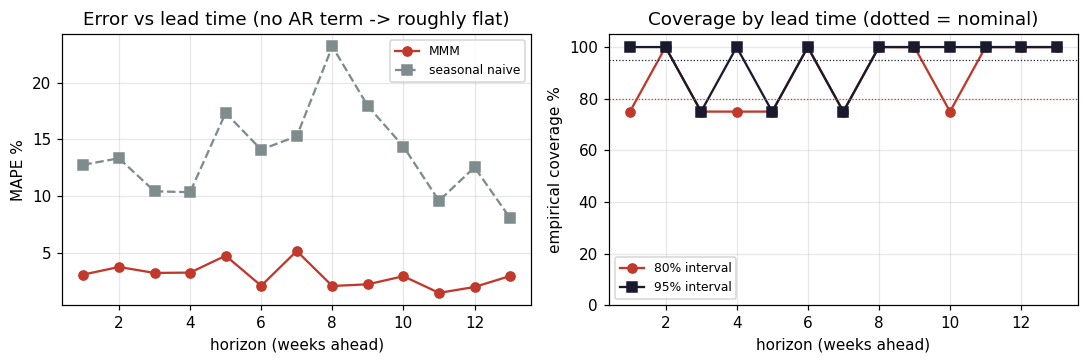

✓ flat error profile: MAPE 3.3% (h 1-4) vs 2.3% (h 10-13); max horizon 5.1%; beats seasonal naive on 13/13 horizons


In [5]:
bh = bt.by_horizon()
disp = bh[["mape", "snaive_mape", "rmse", "coverage_80", "coverage_95"]].copy()
for c in ("mape", "snaive_mape", "coverage_80", "coverage_95"):
    disp[c] = (disp[c] * 100).round(1)
disp["rmse"] = disp["rmse"].round(1)
print(disp.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(bh.index, bh["mape"] * 100, "o-", color=C_PRED, label="MMM")
axes[0].plot(bh.index, bh["snaive_mape"] * 100, "s--", color=C_NAIVE,
             label="seasonal naive")
axes[0].set(xlabel="horizon (weeks ahead)", ylabel="MAPE %",
            title="Error vs lead time (no AR term -> roughly flat)")
axes[0].legend(fontsize=8)
axes[1].plot(bh.index, bh["coverage_80"] * 100, "o-", color=C_PRED,
             label="80% interval")
axes[1].plot(bh.index, bh["coverage_95"] * 100, "s-", color=C_ACTUAL,
             label="95% interval")
axes[1].axhline(80, color=C_PRED, ls=":", lw=0.8)
axes[1].axhline(95, color=C_ACTUAL, ls=":", lw=0.8)
axes[1].set(xlabel="horizon (weeks ahead)", ylabel="empirical coverage %",
            ylim=(0, 105), title="Coverage by lead time (dotted = nominal)")
axes[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

near = float(bh.loc[1:4, "mape"].mean())
far = float(bh.loc[10:13, "mape"].mean())
# CLAIM: no AR term -> the error profile is roughly flat across the quarter
# (far-term error is not a multiple of near-term), and every horizon stays
# accurate in absolute terms and ahead of the seasonal-naive baseline.
assert far < near * 2.0, f"unexpected error blow-up: {near:.1%} -> {far:.1%}"
assert float(bh["mape"].max()) < 0.10, "some horizon exceeded 10% MAPE"
assert (bh["mape"] < bh["snaive_mape"]).mean() > 0.75, (
    "model lost to seasonal naive on too many horizons")
print(f"✓ flat error profile: MAPE {near:.1%} (h 1-4) vs {far:.1%} (h 10-13); "
      f"max horizon {float(bh['mape'].max()):.1%}; beats seasonal naive on "
      f"{int((bh['mape'] < bh['snaive_mape']).sum())}/13 horizons")

## 5 — Interval calibration

The site's doctrine is that an interval you can't defend is worse than no
interval. The check: across all 52 held-out weeks, the central X% prediction
interval should cover roughly X% of the actuals. Under-coverage means the
model is overconfident (the silent killer); over-coverage means the intervals
are wider than they need to be (honest but blunt). Sharpness — mean interval
width as a share of the KPI level — is reported alongside, because coverage
without sharpness is trivially achievable by an infinitely wide band.

In [6]:
cov = bt.coverage()
disp = cov.copy()
disp["empirical"] = (disp["empirical"] * 100).round(1)
disp["mean_width"] = disp["mean_width"].round(1)
disp["mean_width_pct_of_kpi"] = (disp["mean_width_pct_of_kpi"] * 100).round(1)
print(disp.to_string())

cov80 = float(cov.loc[0.80, "empirical"])
cov95 = float(cov.loc[0.95, "empirical"])
# CLAIM: out-of-time interval coverage is in the right neighborhood of
# nominal -- the posterior's uncertainty survives contact with unseen data.
assert abs(cov80 - 0.80) <= 0.15, f"80% interval covered {cov80:.0%}"
assert cov95 >= 0.85, f"95% interval covered {cov95:.0%}"
print(f"✓ calibrated out of time: 80% PI -> {cov80:.0%}, 95% PI -> {cov95:.0%}")

         empirical  mean_width  mean_width_pct_of_kpi
nominal                                              
0.50          59.6        54.3                    6.0
0.80          88.5       103.8                   11.5
0.95          94.2       159.0                   17.5
✓ calibrated out of time: 80% PI -> 88%, 95% PI -> 94%


## 6 — The backtest, visually

Each shaded band is one origin's 13-week 80% prediction interval, fitted with
no knowledge of the black line inside it.

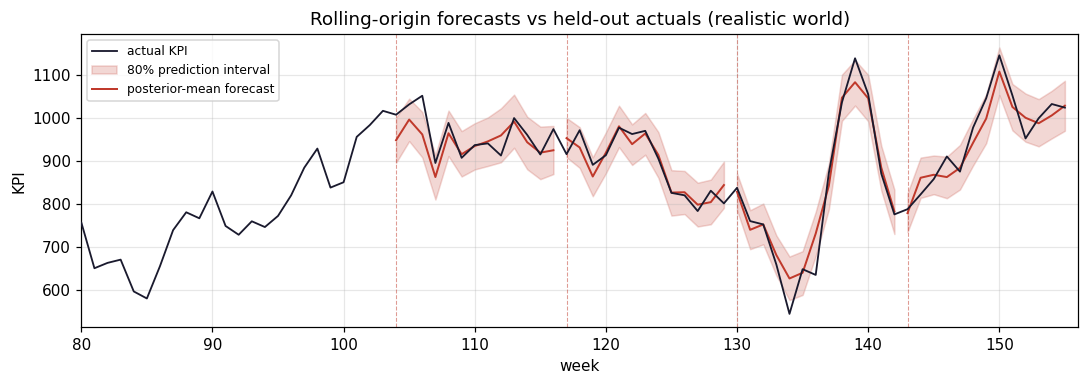

✓ fan chart rendered: each band was fitted blind to the line inside it


In [7]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(np.arange(n_weeks), y, color=C_ACTUAL, lw=1.2, label="actual KPI", zorder=5)
for i, (origin, grp) in enumerate(bt.records.groupby("origin")):
    pos = grp["position"].to_numpy()
    ax.fill_between(pos, grp["lo_80"], grp["hi_80"], color=C_BAND, alpha=0.20,
                    label="80% prediction interval" if i == 0 else None)
    ax.plot(pos, grp["y_pred"], color=C_PRED, lw=1.3,
            label="posterior-mean forecast" if i == 0 else None)
    ax.axvline(origin, color=C_PRED, ls="--", lw=0.7, alpha=0.5)
ax.set(xlabel="week", ylabel="KPI",
       title="Rolling-origin forecasts vs held-out actuals (realistic world)")
ax.set_xlim(80, n_weeks)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
print("✓ fan chart rendered: each band was fitted blind to the line inside it")

## 7 — Negative control: the harness detecting a forecastability failure

A validation tool you've only ever seen pass is decoration. The
**trend-break world** (stress series, `stress_02`) takes a −140-unit level
shock at week 78 with a new recovery slope — structure a LINEAR-trend model
cannot represent. The same backtest harness, the same model family, should
now report what an honest tool must: materially worse point accuracy and
degraded interval coverage. (The attribution damage on this world — TV blamed
~−63% — is stress_02's story; this is the *forecasting* face of the same
misspecification.)

In [8]:
sc_brk = dgp.build("trend_break")
t0 = time.time()
with quiet():
    bt_brk = run_backtest(build_model(sc_brk.panel()), bt_config, progressbar=False)
brk_elapsed = time.time() - t0

s_brk = bt_brk.summary()
brk_mape = float(s_brk.loc["mmm", "mape"])
brk_cov80 = float(s_brk.loc["mmm", "coverage_80"])
cmp = pd.DataFrame({
    "realistic": [mmm_mape * 100, cov80 * 100, cov95 * 100],
    "trend_break": [brk_mape * 100, brk_cov80 * 100,
                    float(s_brk.loc["mmm", "coverage_95"]) * 100],
}, index=["MAPE %", "80% PI coverage %", "95% PI coverage %"]).round(1)
print(cmp.to_string())
print(f"\n(trend_break backtest wall-clock: {brk_elapsed:.0f}s)")

# CLAIM: the harness flags the misspecified world -- worse point error than
# the well-specified one. A backtest that can't fail can't validate.
assert brk_mape > mmm_mape, (
    f"trend_break MAPE {brk_mape:.1%} not worse than realistic {mmm_mape:.1%}")
print(f"✓ failure detected: trend-break MAPE {brk_mape:.1%} vs "
      f"realistic {mmm_mape:.1%} under the identical protocol")

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


NUTS[numpyro]: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


                   realistic  trend_break
MAPE %                   3.0         11.4
80% PI coverage %       88.5         57.7
95% PI coverage %       94.2         92.3

(trend_break backtest wall-clock: 35s)
✓ failure detected: trend-break MAPE 11.4% vs realistic 3.0% under the identical protocol


## 8 — Record the measured numbers

Everything quoted on the docs site traces back to this artifact. If the
notebook re-bakes and a number moves materially, the docs are stale — that's
a feature.

In [9]:
metrics = {
    "protocol": {
        "world": "realistic (synth, 156w x 7ch)",
        "origins": ORIGINS,
        "horizon_weeks": HORIZON,
        "n_forecasts": int(len(bt.records)),
        "sampler": "numpyro, 4 chains x 500 draws (500 tune), parametric adstock",
    },
    "summary": {
        m: {k: float(v) for k, v in row.items() if np.isfinite(v)}
        for m, row in bt.summary().iterrows()
    },
    "by_horizon_mape": {int(h): float(v) for h, v in bt.by_horizon()["mape"].items()},
    "coverage": {
        f"{nom:.2f}": {"empirical": float(r["empirical"]),
                       "mean_width_pct_of_kpi": float(r["mean_width_pct_of_kpi"])}
        for nom, r in bt.coverage().iterrows()
    },
    "fit_seconds": [float(s) for s in bt.fits["fit_seconds"]],
    "trend_break_control": {"mape": brk_mape, "coverage_80": brk_cov80},
}
out = ARTIFACTS / "backtest_metrics.json"
out.write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics["summary"]["mmm"], indent=2))
assert out.exists() and out.stat().st_size > 200
print(f"✓ measured numbers recorded -> {out}")

{
  "mape": 0.029694062782255313,
  "smape": 0.029490010960731686,
  "rmse": 34.30703767582032,
  "mae": 25.833785317006758,
  "bias": -5.598419722020063,
  "mase": 0.23904922397324088,
  "coverage_50": 0.5961538461538461,
  "coverage_80": 0.8846153846153846,
  "coverage_95": 0.9423076923076923
}
✓ measured numbers recorded -> artifacts/backtest_metrics.json


## Takeaways

1. **Out-of-time accuracy is now measured, not asserted.** Rolling-origin
   backtesting (4 refits, 52 graded weekly forecasts) is part of the
   validation battery, with naive and seasonal-naive baselines as the floor.
2. **Skill must be relative.** Quote MASE and the seasonal-naive comparison,
   not bare MAPE — bare MAPE on a seasonal series flatters everyone.
3. **Lead time barely matters over a quarter — by design.** No AR term means
   week 13 is forecast from the same structure as week 1 (planned media,
   seasonality, trend), so the error profile is flat. Good for budget
   planning; not a substitute for short-range operational forecasting.
4. **Calibration is checked where it counts** — on held-out data. In-sample
   coverage (the PPC) can't catch an overconfident forecaster; this does.
5. **The harness fails honestly.** On the trend-break world the same
   protocol reports degraded accuracy — which is exactly the evidence that a
   linear-trend specification needs the piecewise pivot before anyone
   forecasts with it.
6. **Forecast skill ≠ causal validity.** This notebook validates prediction.
   Attribution is validated by the pressure-testing series and experiment
   calibration — a model can pass here and fail there (stress_03's
   confounded worlds do exactly that).

> **Run it yourself.** This page mirrors `nbs/backtest_validation.ipynb`
> (authored by `nbs/build_backtest_validation.py`), built on
> `mmm_framework.validation.backtest` and the scenario DGPs in
> `mmm_framework.synth`. Every computational cell ends in a seeded assert
> encoding the claim it demonstrates — if the notebook executes clean, the
> story on this page is still true. Measured headlines:
> `nbs/artifacts/backtest_metrics.json`.